In [1]:
#!/usr/bin/env python
# coding: utf-8
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon


def formal_comparison(pair1, pair2):

    for method in pair1["method"].unique():
        x = np.array(pair1[pair1["method"] == method]["delta"])
        y = np.array(pair2[pair2["method"] == method]["delta"])
        print(method)
        print(wilcoxon(x, y))

def load_pair(treated_file, control_file, treated_col="blocks", control_col="noblocks"):
    df1 = pd.read_csv(treated_file).rename(columns={"score": treated_col})
    df2 = pd.read_csv(control_file).rename(columns={"score": control_col})
    pair = df1.merge(df2, on=["doc_id", "method", "membership"])
    pair["delta"] = pair[treated_col] - pair[control_col]
    pair = pair[pair["membership"] == "member"].copy()
    return pair


def report_att(df):
    print(df[["delta", "method"]].groupby(["method"]).mean().reset_index())



control_file = 'csvs/sutva_click2houston_com_2022-05-01_pair2_control_run4_sutva_click2houston_com_2022-05-01_pair2_control_run4_filtered.csv'
treated1 = 'csvs/sutva_click2houston_com_2022-05-01_pair1_treated_run1_sutva_click2houston_com_2022-05-01_pair2_control_run4_filtered.csv'
treated2 = 'csvs/sutva_click2houston_com_2022-05-01_pair2_treated_run3_sutva_click2houston_com_2022-05-01_pair2_control_run4_filtered.csv'

pair1 = load_pair(treated1, control_file)
pair2 = load_pair(treated2, control_file)

formal_comparison(pair1, pair2)

procd = pd.read_csv("data/processed/sutva_click2houston_com_2022-05-01_pair2_control_run4_filtered_aggregated_results.tsv", sep="\t")
procd = procd.rename(columns={"url": "doc_id"})

pair1 = pair1.merge(procd, on=["doc_id"])
pair1.columns = [o.replace('sutva_click2houston_com_2022-05-01_', '') for o in pair1.columns]
pair1["delta_count_median"] = pair1["pair1_treated_run1_median_count"] - pair1["pair2_control_run4_median_count"]
pair1["delta_count_mean"] = pair1["pair1_treated_run1_mean_count"] - pair1["pair2_control_run4_mean_count"]

pair2 = pair2.merge(procd,  on=["doc_id"])
pair2.columns = [o.replace('sutva_click2houston_com_2022-05-01_', '') for o in pair2.columns]
pair2["delta_count_median"] = pair1["pair2_treated_run3_median_count"] - pair1["pair2_control_run4_median_count"]
pair2["delta_count_mean"] = pair1["pair2_treated_run3_mean_count"] - pair1["pair2_control_run4_mean_count"]


report_att(pair1)
report_att(pair2)



loss
WilcoxonResult(statistic=32731.0, pvalue=0.0)
min_k
WilcoxonResult(statistic=160209.0, pvalue=0.0)
zlib
WilcoxonResult(statistic=64264.0, pvalue=0.0)
  method     delta
0   loss  1.716169
1  min_k  2.239866
2   zlib  0.001649
  method     delta
0   loss  2.075783
1  min_k  2.731475
2   zlib  0.001973


In [10]:
for method in ["loss"]:
    print(method)
    for p in [pair1, pair2]:
        T = p[p["method"] == method].copy()
        print(T[['delta_count_median', 'delta']].corr(method="kendall"))
        #print(T[['delta_count_mean', 'delta']].corr(method="kendall"))

loss
                    delta_count_median     delta
delta_count_median            1.000000 -0.124706
delta                        -0.124706  1.000000
                    delta_count_median     delta
delta_count_median            1.000000 -0.170892
delta                        -0.170892  1.000000


In [2]:
from scipy.stats import kendalltau
from scipy.stats import pearsonr
from scipy.stats import spearmanr


AGG = "median"

FIELD = f"delta_count_{AGG}"


ATEs = pair2[["doc_id", "delta", "method", "membership"]].rename(columns={"delta": "delta_p2"}).merge(pair1[["doc_id", "delta", "method", "membership"]], on=["doc_id", "method", "membership"])
ATEs["delta_ate"] = ATEs["delta_p2"] - ATEs["delta"]
ATEs = ATEs.drop(columns=["delta", "delta_p2"])

ATEs = ATEs[ATEs["method"] == "loss"].copy()

delta_counts = pair2[["doc_id", FIELD, "method", "membership"]].rename(columns={FIELD: f"{FIELD}_p2"}).merge(pair1[["doc_id", FIELD, "method", "membership"]], on=["doc_id", "method", "membership"])
delta_counts["delta_count"] = delta_counts[f"{FIELD}_p2"] - delta_counts[FIELD]
delta_counts = delta_counts.drop(columns=[f"{FIELD}_p2", FIELD])

ATEs = ATEs.merge(delta_counts, on = ['method', "membership", "doc_id"])

ATEs["abs_delta_ate"] = ATEs["delta_ate"].apply(lambda x: abs(x))
ATEs["abs_delta_count"] = ATEs["delta_count"].apply(lambda x: abs(x))

ATEs[["abs_delta_ate", "abs_delta_count"]].corr(method='kendall')

tau, pval = kendalltau(ATEs["abs_delta_ate"], ATEs["abs_delta_count"])

print(tau, pval)

0.0867402039204099 1.2674122640433688e-14


In [7]:
fn = "/Users/abha4861/dolma/data/interim/sutva/results/sutva_click2houston_com_2022-05-01_pair2_control_run4_filtered_in_sutva_click2houston_com_2022-05-01_pair2_control_run4_top1000_analysis_threshold0p9.csv"

card = pd.read_csv(fn)
card = card.rename(columns={"url": "doc_id"})

In [9]:
pair1 = pair1.merge(card, on='doc_id')
pair2 = pair2.merge(card, on='doc_id')

In [21]:
pair1[["delta", "sutva_click2houston_com_2022-05-01_pair1_treated_run1"]].corr(method="kendall")

,delta,sutva_click2houston_com_2022-05-01_pair1_treated_run1
delta,1.000000,-0.055465
sutva_click2houston_com_2022-05-01_pair1_treated_run1,-0.055465,1.000000


In [20]:
pair1[["pair1_treated_run1_mean_count", "sutva_click2houston_com_2022-05-01_pair1_treated_run1"]].corr(method="kendall")

,pair1_treated_run1_mean_count,sutva_click2houston_com_2022-05-01_pair1_treated_run1
pair1_treated_run1_mean_count,1.000000,0.134062
sutva_click2houston_com_2022-05-01_pair1_treated_run1,0.134062,1.000000


### Card

In [38]:
import pandas as pd
df = pd.read_csv("csvs/sutva_click2houston_com_2022-05-01_pair2_control_run4_neighbors_top100.csv")
df = df[df["method"] == "loss"].copy()
df2score = {k: v for k, v in zip(df["doc_id"], df["score"])}

In [118]:
import gzip
import json

fn = "data/interim/sutva/results/sutva_click2houston_com_2022-05-01_pair2_control_run4_in_sutva_click2houston_com_2022-05-01_pair2_control_run4_top100.jsonl.gz"

vectors = []

with gzip.open(fn, "rt") as f:
    for line in f:
        row = json.loads(line)
        query_url = row["query_url"]
        embed = row["query_embedding"]
        vectors.append({"query_url": query_url, "embed": embed})
        for neighbor in row["neighbors"]:
            url = neighbor["url"]
            embed = neighbor["embedding"]
            vectors.append({"query_url": url, "embed": embed})

vectors = pd.DataFrame(vectors)

vectors = vectors[vectors["query_url"].apply(lambda x: x in df2score)].copy()

vectors["score"] = vectors["query_url"].apply(lambda x: df2score[x])

In [123]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

data = []

for _ in range(10000):
    pair = vectors.sample(2)
    v1 = np.array(pair.iloc[0]["embed"]).reshape(1, -1)
    v2 = np.array(pair.iloc[1]["embed"]).reshape(1, -1)
    cossim = cosine_similarity(v1, v2)[0, 0]
    distance = 1 - cossim
    lg_score = np.log(1e-10 + abs(pair.iloc[0]["score"] - pair.iloc[1]["score"]))
    delta_lg_score = np.log(pair.iloc[0]["score"]) - np.log(pair.iloc[1]["score"])
    delta_score = (pair.iloc[0]["score"]) - (pair.iloc[1]["score"])
    data.append({"cos": cossim, "lg_score": lg_score, 
                 "delta_score": delta_score,
                 "delta_lg_score": delta_lg_score, "distance": distance})
    
data = pd.DataFrame(data)
data.corr(method='kendall')

,cos,lg_score,delta_score,delta_lg_score,distance
cos,1.000000,0.010587,0.003990,0.003848,-1.000000
lg_score,0.010587,1.000000,0.003612,0.002143,-0.010587
delta_score,0.003990,0.003612,1.000000,0.951749,-0.003990
delta_lg_score,0.003848,0.002143,0.951749,1.000000,-0.003848
distance,-1.000000,-0.010587,-0.003990,-0.003848,1.000000


- We plot it like this because the correlation between a vector and a scalar (score) is undefined. 

<Axes: xlabel='cos', ylabel='delta_score'>

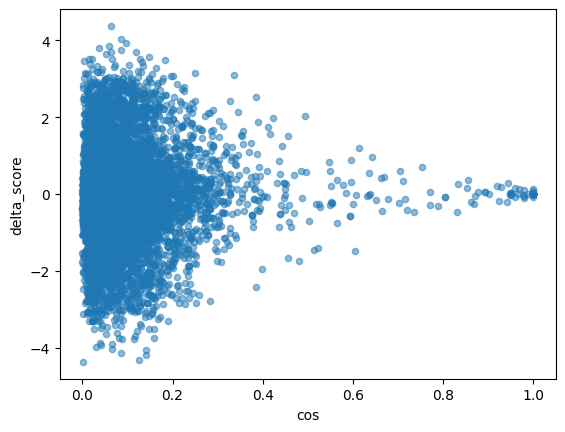

In [127]:
data[data["cos"] > 0].plot.scatter(x="cos", y="delta_score", alpha=.5)

In [131]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import pickle

def fit_topic_to_score(vectors_df, embed_col="embed", score_col="score", 
                       cv_folds=5, test_size=0.2, alpha=1.0):
    """
    Fit linear regression from topic embeddings to continuous score.
    
    Parameters:
    -----------
    vectors_df : DataFrame with embed and score columns
    embed_col : column name containing embedding vectors
    score_col : column name containing scores
    cv_folds : number of cross-validation folds
    test_size : fraction held out for final test
    alpha : Ridge regularization strength
    
    Returns:
    --------
    dict with model, metrics, and predictions
    """
    
    # Stack embeddings into matrix
    X = np.vstack(vectors_df[embed_col].values)
    y = vectors_df[score_col].values
    
    print(f"X shape: {X.shape}")
    print(f"Y range: [{y.min():.3f}, {y.max():.3f}], mean: {y.mean():.3f}, std: {y.std():.3f}")
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    
    # Fit model (Ridge to handle high-dim embeddings)
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    
    # Cross-validation on training set
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv_folds, scoring='r2')
    
    # Test set evaluation
    y_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"\nCV R²: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")
    print(f"Test R²: {test_r2:.3f}")
    print(f"Test RMSE: {test_rmse:.3f}")
    
    return {
        'model': model,
        'cv_r2': cv_scores.mean(),
        'cv_r2_std': cv_scores.std(),
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred
    }


def predict_score(model_dict, new_embeddings):
    """Predict scores for new embeddings."""
    if isinstance(new_embeddings, list):
        new_embeddings = np.vstack(new_embeddings)
    return model_dict['model'].predict(new_embeddings)


results = fit_topic_to_score(vectors[["embed", "score"]])

X shape: (1007, 768)
Y range: [0.135, 4.838], mean: 2.578, std: 0.817

CV R²: 0.792 (+/- 0.126)
Test R²: 0.833
Test RMSE: 0.336
